# Synthetic example

This synthetic case follows the paper of Günther & Martin (2016) using a Cole-Cole model. A slag heap consists of two different bodies with different time constants.

In [1]:
import numpy as np
from fdip import FDIP
from pygimli.physics import ert
import pygimli.meshtools as mt


In [2]:
data = ert.createData(41, "dd")
print(data)

02/07/26 - 17:47:07 - pyGIMLi - INFO - Cache c:\src\ERT\TDIP\.venv\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 1): C:\Users\Thomas Guenther\AppData\Roaming\pygimli\Cache\4851767410368674125


Data: Sensors: 41 data: 741, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


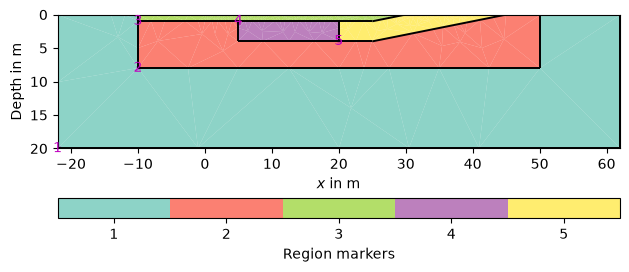

In [3]:
poly = mt.createParaMeshPLC(data, paraDX=0.2, paraDepth=8,
                            paraBoundary=10, boundary=0.3)
topsoil = [[-10, -1], [25, -1], [30, 0], [-10, 0]]
poly += mt.createPolygon(topsoil, isClosed=True, marker=3)
slag1 = [[5, -1], [5, -4], [20, -4], [20, -1]]
poly += mt.createPolygon(slag1, isClosed=True, marker=4)
slag2 = [[20, -4], [25, -4], [45, 0], [30, 0], [25, -1], [20, -1]]
poly += mt.createPolygon(slag2, isClosed=True, marker=5)
poly.show();

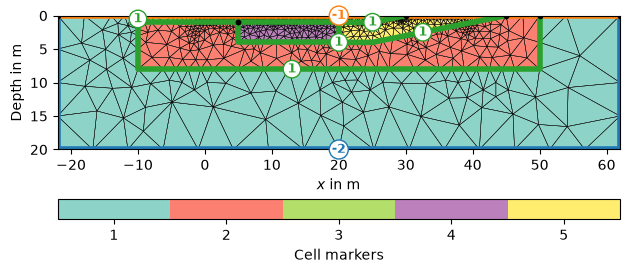

In [4]:
mesh = mt.createMesh(poly)
mesh.show(markers=True, showMesh=True);

In [12]:
frvec = [0.156, 0.312, 0.625, 1.25, 2.5, 5, 10, 20, 40, 80, 125,
         250, 500, 1000]
pro = FDIP(data=data, f=frvec)

In [ ]:
pro.simulate(mesh,
             rhovec=np.array([200, 200, 500., 100., 200., 200.]),
             mvec=np.array([1e-3, 1e-3, 1e-3, 1e-3, 0.1, 1.0]),
             tauvec=np.array([0, 0, 1e-5, 1e-5, 0.8, 0.7]),
             cvec=np.array([0, 0, 0.25, 0.25, 0.5, 0.5]));

02/07/26 - 17:51:01 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:01 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:01 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:02 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:02 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:02 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:03 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:03 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:03 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:03 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:04 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:04 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:04 - pyGIMLi - INFO - Complex resistivity values found.
02/07/26 - 17:51:05 - pyGIMLi - INFO - Complex resi

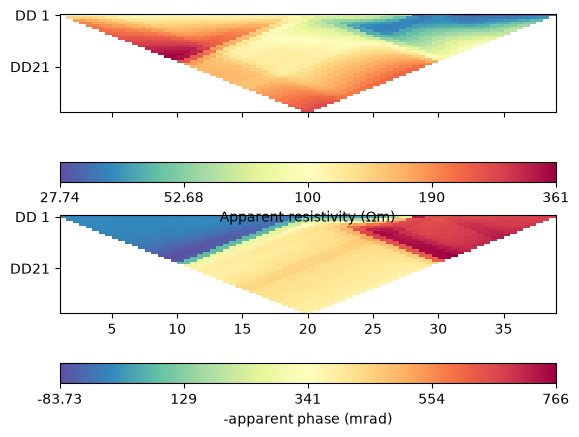

In [15]:
pro.showSingleFrequencyData(5);

02/07/26 - 17:51:41 - pyGIMLi - INFO - Found 2 regions.
02/07/26 - 17:51:41 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
02/07/26 - 17:51:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/07/26 - 17:51:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/07/26 - 17:51:41 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3157 Cells: 6024 Boundaries: 4662
02/07/26 - 17:51:41 - pyGIMLi - INFO - Use median(data values)=197.0862466034703




WARNING! found negative phases .. taking abs of ip data.


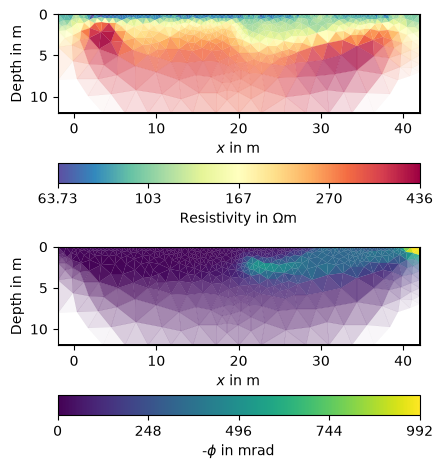

In [16]:
pro.createERTManager(paraDepth=12)
pro.singleInversion()
pro.showSingleResult();

In [17]:
pro.simultaneousInversion()

02/07/26 - 17:52:00 - pyGIMLi - INFO - Found 2 regions.
02/07/26 - 17:52:00 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
02/07/26 - 17:52:00 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/07/26 - 17:52:00 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/07/26 - 17:52:00 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3157 Cells: 6024 Boundaries: 4662
02/07/26 - 17:52:01 - pyGIMLi - INFO - Starting inversion.
02/07/26 - 17:52:01 - pyGIMLi - INFO - fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x00000138955215D0>
02/07/26 - 17:52:01 - pyGIMLi - INFO - Data transformation: Identity transform
02/07/26 - 17:52:01 - pyGIMLi - INFO - Model transformation: Logarithmic transform
02/07/26 - 17:52:01 - pyGIMLi - INFO - min/max (data): 2.13/447
02/07/26 - 17:52:01 - pyGIMLi - INFO - min/max (error): 3.02%/53.71%
02/07/26 - 17:52:01 - pyGIMLi - INFO - min/max (start model): 108/108


868 model cells
--------------------------------------------------------------------------------


02/07/26 - 17:52:12 - pyGIMLi - INFO - inv.iter 0 ... chi² = 22688.74


--------------------------------------------------------------------------------
inv.iter 1 ... 

02/07/26 - 17:52:20 - pyGIMLi - INFO - chi² = 2670.23 (dPhi = 88.22%) lam: 20.0


...

--------------------------------------------------------------------------------
inv.iter 2 ... 

02/07/26 - 17:53:36 - pyGIMLi - INFO - chi² =   26.66 (dPhi = 52.76%) lam: 20.0
02/07/26 - 17:53:40 - pyGIMLi - INFO - chi² =    1.35 (dPhi = 92.16%) lam: 20.0


--------------------------------------------------------------------------------
inv.iter 3 ... --------------------------------------------------------------------------------
inv.iter 4 ... 

02/07/26 - 17:53:43 - pyGIMLi - INFO - chi² =    0.50 (dPhi = 34.67%) lam: 20.0




################################################################################
#                  Abort criterion reached: chi² <= 1 (0.50)                   #
################################################################################


In [18]:
pro.fitAllRhoPhi()

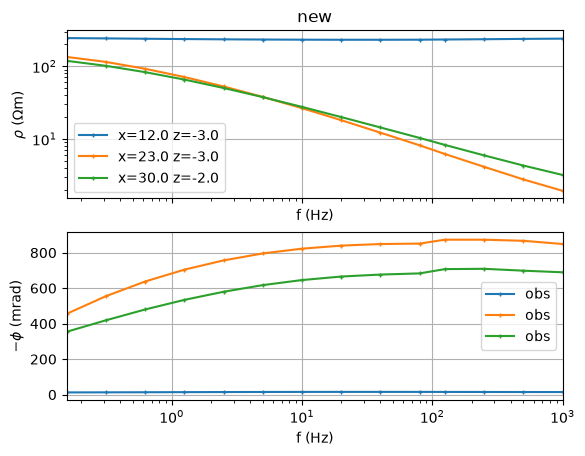

In [19]:
pro.showModelSpectra([[12, -3], [23, -3], [30, -2]]);

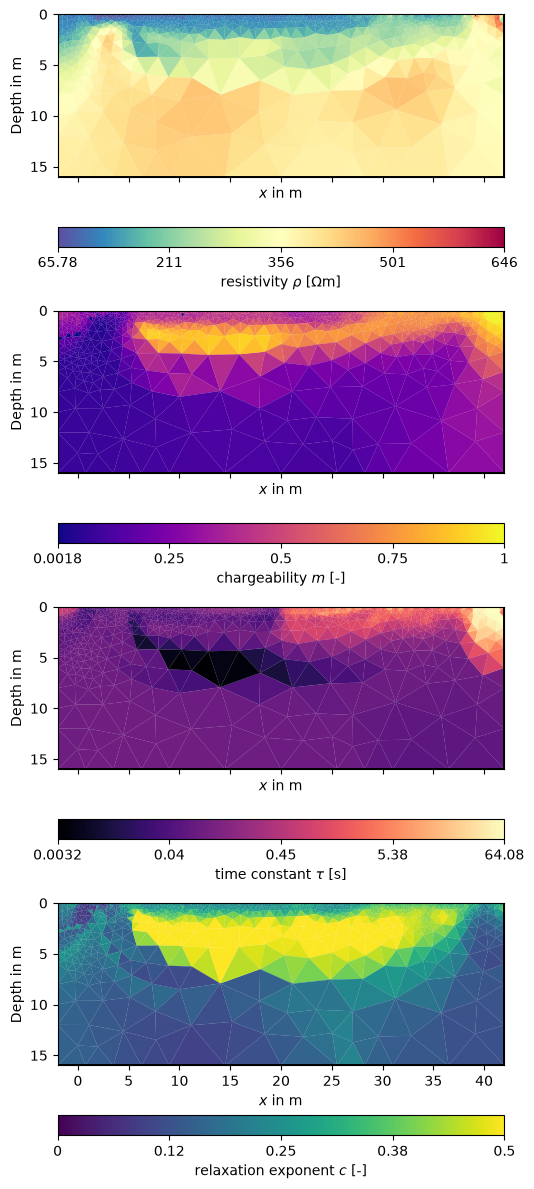

In [11]:
pro.showColeColeParameters(coverage=1);